In [1]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    
 
from fizinfo import *

In [2]:
def onvezeto_v(t):
    vx = np.zeros_like(t)
    vy = np.zeros_like(t)

    # 1. szakasz egyenletes haladas
    maszk_egyenletes = t < 2

    # beállítjuk az egyenletes sebesseget
    vx[maszk_egyenletes] = 10.0
    vy[maszk_egyenletes] = 0.0

    # 2. szakasz: t >= 2s
    maszk_gyorsulo = t >= 2

    # sebességnagyság: 10 m/s-ról gyorsul 0.5 m/s^2-tel, max 30 m/s
    v_nagysag = np.minimum(10.0 + 0.5 * (t - 2), 30.0)

    # irányszög (radiánban)
    phi = np.radians(20) * np.sin((2 * np.pi / 12) * (t - 2))

    # sebesség komponensek a 2. szakaszban
    vx[maszk_gyorsulo] = v_nagysag[maszk_gyorsulo] * np.cos(phi[maszk_gyorsulo])
    vy[maszk_gyorsulo] = v_nagysag[maszk_gyorsulo] * np.sin(phi[maszk_gyorsulo])

    return np.column_stack([vx, vy])  # (N, 2) alakú tömb, ahogy num_kinem várja

In [ ]:
# a) Ábrázolja a jármű pályáját az első 100 másodpercben! (3 p)
jarmu=num_kinem(2)   # 2D kinematikai számítások
jarmu.set_time_range(0.0, 100.0, 0.01)

# fontos hogy itt milyen függvényt adok át, út, sebesség stb.. stb..
jarmu.set_v_fun(onvezeto_v)
jarmu.calc_v_to_r()
jarmu.calc_v_to_a()

#jarmu.plot_rcomp()

In [34]:
# b) Milyen széles és milyen hosszú aszfaltozott terület kell ahhoz, 
# hogy az autó ne fusson le róla eközben? (3 p)

# Kikeressük az X (0. oszlop) és Y (1. oszlop) koordináták minimumát és maximumát
x_min = jarmu.r[:, 0].min()
x_max = jarmu.r[:, 0].max()

y_min = jarmu.r[:, 1].min()
y_max = jarmu.r[:, 1].max()

# A téglalap méreteit a maximum és minimum értékek távolsága (különbsége) adja meg
szelesseg = x_max - x_min
magassag = y_max - y_min

print(f'A tesztpálya minimális mérete: {szelesseg:.2f} m széles és {magassag:.2f} m hosszú.')

A tesztpálya minimális mérete: 2483.65 m széles és 39.46 m hosszú.


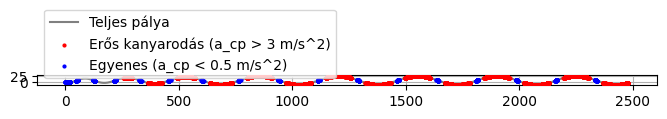

In [39]:
# c) Készítsen ábrát, melyen az autó pályája szürke,
# és rajta pirossal az erős kanyarodási részek vannak bejelölve, azaz azok, ahol az oldalgyorsulás 3 m/s²-nál nagyobb volt,
# kékkel pedig a közel egyenes részek. (4 p)

jarmu.calc_at_acp_Rinv()

# Egyenes vonalú mozgásnál alig van irányváltoztatás, tehát a centripetális gyorsulás közel nulla.
# Készítünk egy maszkot, ami ott True, ahol az a_cp nagyon kicsi (< 0.5 m/s^2).
egyenes = jarmu.a_cp_abs < 0.5
eros_kanyar = jarmu.a_cp_abs > 3

fig = plt.figure(figsize=(8,8))  
ax1 = plt.subplot(111)

# A teljes pályagörbét kirajzoljuk szürkével
ax1.plot(jarmu.r[:,0], jarmu.r[:,1], color="grey", label="Teljes pálya")  

# A maszkot alkalmazva pirossal rajzoljuk az erős kanyarodás szakaszait
ax1.scatter(jarmu.r[eros_kanyar,0], jarmu.r[eros_kanyar,1], 
            color="red", s=4, zorder=4, label="Erős kanyarodás (a_cp > 3 m/s^2)")  

# A maszkot alkalmazva kékkel rajzoljuk a majdnem egyenes szakaszokat a vonal fölé (zorder=3)
ax1.scatter(jarmu.r[egyenes,0], jarmu.r[egyenes,1], 
            color="blue", s=4, zorder=3, label="Egyenes (a_cp < 0.5 m/s^2)")  

ax1.set_aspect(aspect='equal') # Torzításmentes megjelenítés (kör alakú marad a pálya)
ax1.legend()
ax1.grid()
plt.show()

In [40]:
# d) Ha egy automatika leállítja a mozgást 2 km (2000 m) megtett út után, 
# akkor hol és mikor áll le?

jarmu.calc_pathlength()

# 1. Megkeressük a 2000 méterhez legközelebbi érték indexét
# Kiszámoljuk az eltérések abszolút értékét, és az argmin() megadja a legkisebb eltérés helyét
leallasi_idx = np.abs(jarmu.pathlength - 2000).argmin()

# 2. Az index segítségével kimásoljuk a pontos időpontot és koordinátákat
t_leallas = jarmu.t[leallasi_idx]
x_leallas = jarmu.r[leallasi_idx, 0]
y_leallas = jarmu.r[leallasi_idx, 1]
ut_leallas = jarmu.pathlength[leallasi_idx]

# 3. Kiíratjuk az eredményeket
print(f"Az autó {t_leallas:.2f} s után áll le.")
print(f"A leállás helye: X = {x_leallas:.2f} m, Y = {y_leallas:.2f} m.")
print(f"(Ellenőrzésképpen a pontos megtett út ekkor: {ut_leallas:.2f} m)")

Az autó 81.33 s után áll le.
A leállás helye: X = 1940.88 m, Y = 22.21 m.
(Ellenőrzésképpen a pontos megtett út ekkor: 1999.90 m)
